## Importing Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
from tqdm import tqdm
import warnings
import os

### Import Dataset

In [9]:
meta = pd.read_csv("ECG_Processed_Dataset/ecg_meta.csv")
signals = np.load("ECG_Processed_Dataset/ecg_signals.npy", allow_pickle=True)

meta["signal"] = signals
df = meta

In [10]:
df

,record_id,label,length,signal
0,A00001,N,9000,"[-0.127, -0.162, -0.197, -0.229, -0.245, -0.25..."
1,A00002,N,9000,"[0.128, 0.157, 0.189, 0.226, 0.25, 0.257, 0.26..."
2,A00003,N,18000,"[0.056, 0.073, 0.085, 0.093, 0.1, 0.107, 0.113..."
3,A00004,A,9000,"[0.519, 0.619, 0.723, 0.827, 0.914, 0.956, 0.9..."
4,A00005,A,18000,"[-0.188, -0.239, -0.274, -0.316, -0.356, -0.37..."
...,...,...,...,...
8523,A08524,N,9000,"[-0.104, -0.127, -0.144, -0.154, -0.16, -0.164..."
8524,A08525,O,9000,"[-0.121, -0.197, -0.288, -0.39, -0.496, -0.6, ..."
8525,A08526,N,10904,"[-0.202, -0.235, -0.272, -0.305, -0.325, -0.33..."
8526,A08527,N,9000,"[-0.227, -0.297, -0.374, -0.449, -0.505, -0.52..."


### Feature Extraction

In [17]:
FS = 300  # sampling frequency

In [18]:
SAVE_PATH   = "ECG_Processed_Dataset/ecg_features.csv"

In [19]:
def extract_ecg_features(signal, fs=FS):
    try:
        # 1. Clean signal
        cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")

        # 2. R-peaks
        _, rpeaks_dict = nk.ecg_peaks(cleaned, sampling_rate=fs)
        rpeaks = rpeaks_dict["ECG_R_Peaks"]

        if len(rpeaks) < 4:
            return None

        # 3. RR interval features (most important for AF)
        rr_intervals = np.diff(rpeaks) / fs * 1000  # ms

        rr_features = {
            "rr_mean":          np.mean(rr_intervals),
            "rr_std":           np.std(rr_intervals),
            "rr_min":           np.min(rr_intervals),
            "rr_max":           np.max(rr_intervals),
            "rr_range":         np.max(rr_intervals) - np.min(rr_intervals),
            "rr_cv":            np.std(rr_intervals) / (np.mean(rr_intervals) + 1e-8),
            "rr_median":        np.median(rr_intervals),
            "rr_iqr":           np.percentile(rr_intervals, 75) - np.percentile(rr_intervals, 25),
            "rr_skewness":      float(pd.Series(rr_intervals).skew()),
            "rr_kurtosis":      float(pd.Series(rr_intervals).kurtosis()),
            "num_rpeaks":       len(rpeaks),
            # Successive differences, key AF discriminators
            "rmssd":            np.sqrt(np.mean(np.diff(rr_intervals) ** 2)),
            "sdsd":             np.std(np.diff(rr_intervals)),
            "pnn50":            np.sum(np.abs(np.diff(rr_intervals)) > 50) / len(rr_intervals),
            "pnn20":            np.sum(np.abs(np.diff(rr_intervals)) > 20) / len(rr_intervals),
        }

        # 4. HRV time domain only (reliable on 30s signals)
        # Suppress the DFA warning since it is expected for short recordings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            hrv_time = nk.hrv_time(rpeaks_dict, sampling_rate=fs, show=False)

        hrv_features = {}
        # Only keep time domain columns, skip nonlinear and frequency
        safe_cols = [
            "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD",
            "HRV_pNN50", "HRV_pNN20", "HRV_MedianNN", "HRV_MadNN",
            "HRV_MCVNN", "HRV_IQRNN", "HRV_Prc20NN", "HRV_Prc80NN",
            "HRV_HTI", "HRV_TINN"
        ]
        for col in safe_cols:
            if col in hrv_time.columns:
                val = hrv_time[col].values[0]
                hrv_features[col] = float(val) if not np.isnan(val) else 0.0

        # 5. Signal morphology features
        morph_features = {
            "ecg_mean":         float(np.mean(cleaned)),
            "ecg_std":          float(np.std(cleaned)),
            "ecg_skewness":     float(pd.Series(cleaned).skew()),
            "ecg_kurtosis":     float(pd.Series(cleaned).kurtosis()),
            "ecg_energy":       float(np.sum(cleaned ** 2)),
            "ecg_p2p":          float(np.max(cleaned) - np.min(cleaned)),
            "ecg_rms":          float(np.sqrt(np.mean(cleaned ** 2))),
        }

        # 6. R-peak amplitude features
        r_amplitudes = cleaned[rpeaks]
        amp_features = {
            "r_amp_mean":       float(np.mean(r_amplitudes)),
            "r_amp_std":        float(np.std(r_amplitudes)),
            "r_amp_cv":         float(np.std(r_amplitudes) / (np.mean(r_amplitudes) + 1e-8)),
        }

        # Combine all
        features = {}
        features.update(rr_features)
        features.update(hrv_features)
        features.update(morph_features)
        features.update(amp_features)

        return features

    except Exception:
        return None  # silently skip failed records

### Extract Features for all records

In [20]:
def extract_all_features(df, fs=FS, save_path=None, checkpoint_every=500):
    """
    Extract features with checkpointing. If interrupted, resumes from last save.
    """
    # Resume from checkpoint if exists
    if save_path and os.path.exists(save_path):
        existing_df  = pd.read_csv(save_path)
        done_ids     = set(existing_df["record_id"].values)
        remaining_df = df[~df["record_id"].isin(done_ids)].reset_index(drop=True)
        all_features = existing_df.to_dict("records")
        print(f"Resuming from checkpoint: {len(done_ids)} already done, "
              f"{len(remaining_df)} remaining")
    else:
        remaining_df = df
        all_features = []
        done_ids     = set()

    failed = []

    for _, row in tqdm(remaining_df.iterrows(), total=len(remaining_df),
                       desc="Extracting features"):
        signal    = np.array(row["signal"])
        record_id = row["record_id"]
        label     = row["label"]

        # Suppress ALL warnings during extraction, we know about them
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            features = extract_ecg_features(signal, fs=fs)

        if features is not None:
            features["record_id"] = record_id
            features["label"]     = label
            all_features.append(features)
        else:
            failed.append(record_id)

        # Checkpoint every N records
        if save_path and len(all_features) % checkpoint_every == 0:
            pd.DataFrame(all_features).to_csv(save_path, index=False)

    # Final save
    features_df = pd.DataFrame(all_features)
    if save_path:
        features_df.to_csv(save_path, index=False)

    print(f"\nSuccessfully extracted: {len(features_df)} records")
    print(f"Failed:                 {len(failed)} records")
    print(f"Features per record:    {features_df.shape[1] - 2}")

    return features_df

In [21]:
features_df = extract_all_features(df, save_path=SAVE_PATH, checkpoint_every=500)

Extracting features: 100%|██████████| 8528/8528 [01:24<00:00, 101.29it/s]



Successfully extracted: 8519 records
Failed:                 9 records
Features per record:    39


In [22]:
features_df.shape

(8519, 41)

In [23]:
features_df.head()

,rr_mean,rr_std,rr_min,rr_max,rr_range,rr_cv,rr_median,rr_iqr,rr_skewness,rr_kurtosis,...,ecg_skewness,ecg_kurtosis,ecg_energy,ecg_p2p,ecg_rms,r_amp_mean,r_amp_std,r_amp_cv,record_id,label
0,757.179487,42.811044,586.666667,820.000000,233.333333,0.056540,756.666667,60.000000,-1.434828,4.917027,...,2.109971,8.247574,208.767883,1.476220,0.152304,0.654022,0.115811,0.177075,A00001,N
1,878.383838,235.920892,346.666667,1080.000000,733.333333,0.268585,990.000000,196.666667,-1.397801,0.431706,...,2.466385,11.159622,207.472216,1.648560,0.151830,0.638539,0.204725,0.320614,A00002,N
2,763.593074,140.044073,436.666667,1556.666667,1120.000000,0.183401,746.666667,70.000000,3.737156,18.819404,...,-1.236892,5.648837,332.342932,1.377767,0.135880,0.114191,0.100920,0.883780,A00003,N
3,947.111111,178.855898,716.666667,1340.000000,623.333333,0.188844,921.666667,298.333333,0.494740,-0.911886,...,3.031143,10.748703,308.325324,1.280036,0.185090,0.951996,0.097336,0.102245,A00004,A
4,538.287462,219.984067,313.333333,1090.000000,776.666667,0.408674,450.000000,236.666667,1.238456,0.220579,...,1.732171,5.625704,572.661140,1.657928,0.178366,0.695200,0.107460,0.154575,A00005,A


In [24]:
print(f"Features per record: {features_df.shape[1] - 2}")  # minus record_id and label

Features per record: 39


In [25]:
list(features_df.columns)

['rr_mean',
 'rr_std',
 'rr_min',
 'rr_max',
 'rr_range',
 'rr_cv',
 'rr_median',
 'rr_iqr',
 'rr_skewness',
 'rr_kurtosis',
 'num_rpeaks',
 'rmssd',
 'sdsd',
 'pnn50',
 'pnn20',
 'HRV_MeanNN',
 'HRV_SDNN',
 'HRV_RMSSD',
 'HRV_SDSD',
 'HRV_pNN50',
 'HRV_pNN20',
 'HRV_MedianNN',
 'HRV_MadNN',
 'HRV_MCVNN',
 'HRV_IQRNN',
 'HRV_Prc20NN',
 'HRV_Prc80NN',
 'HRV_HTI',
 'HRV_TINN',
 'ecg_mean',
 'ecg_std',
 'ecg_skewness',
 'ecg_kurtosis',
 'ecg_energy',
 'ecg_p2p',
 'ecg_rms',
 'r_amp_mean',
 'r_amp_std',
 'r_amp_cv',
 'record_id',
 'label']

### ML Model Training

In [26]:
!pip install xgboost imblearn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.4 MB/s eta 0:00:31
    --------------------------------------- 1.3/101.7 MB 3.5 MB/s eta 0:00:29
    --------------------------------------- 2.1/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 2.6/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 3.4/101.7 MB 3.5 MB/s eta 0:00:29
   - -------------------------------------- 4.2/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 5.0/101.7 MB 3.4 MB/s eta 0:00:29
   -- ------------------------------------- 5.8/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 6.6/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 7.3/101.7 MB 3.5 MB/s eta 0:00:27
   --- ------------------------------------ 8.1/101.7 MB 3.5 MB/s eta 0:00:27
   --- ------------------------------------ 8.7/101.7 MB 3.5 MB/s eta 0

In [41]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# Load features
features_df = pd.read_csv("ECG_Processed_Dataset/ecg_features.csv")

In [29]:
# Drop rows with NaN (failed extractions produce NaN HRV values sometimes)
features_df = features_df.dropna()

In [30]:
features_df.shape

(8517, 41)

In [31]:
label_encoding = {"N": 0, "A": 1, "O": 2, "~": 3}
X = features_df.drop(columns=["record_id", "label"]).values
y = features_df["label"].map(label_encoding).values

In [34]:
# Train/test split at record level
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [35]:
# SMOTE to handle imbalance in feature space (much cleaner than signal augmentation)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [36]:
# Train XGBoost
xgb = XGBClassifier(n_estimators=500, max_depth=6, random_state=42)
xgb.fit(X_train_bal, y_train_bal)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [39]:
print(classification_report(y_test, xgb.predict(X_test),
      target_names=["N", "A", "O", "~"]))

              precision    recall  f1-score   support

           N       0.84      0.87      0.85      1010
           A       0.70      0.69      0.70       148
           O       0.66      0.59      0.63       489
           ~       0.39      0.51      0.44        57

    accuracy                           0.76      1704
   macro avg       0.65      0.66      0.65      1704
weighted avg       0.76      0.76      0.76      1704



In [42]:
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)

0.7617370892018779

In [43]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[877   9 105  19]
 [ 13 102  28   5]
 [148  30 290  21]
 [ 10   4  14  29]]


In [44]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


Raw shape:         (8519, 41)
Missing values:
rr_kurtosis    2
dtype: int64

Shape after dropna: (8517, 41)

Class distribution before split:
  N: 5050
  A: 738
  O: 2446
  ~: 283

Train size: 6813  |  Test size: 1704

Class distribution after SMOTE:
  N: 4040
  A: 4040
  O: 4040
  ~: 4040

  XGBoost

Accuracy:    0.7729  (77.29%)
Macro F1:    0.6714
AF F1:       0.7383

Classification Report:
              precision    recall  f1-score   support

  Normal (N)     0.8397    0.8713    0.8552      1010
      AF (A)     0.7333    0.7432    0.7383       148
   Other (O)     0.6939    0.6074    0.6478       489
   Noisy (~)     0.3846    0.5263    0.4444        57

    accuracy                         0.7729      1704
   macro avg     0.6629    0.6871    0.6714      1704
weighted avg     0.7734    0.7729    0.7718      1704



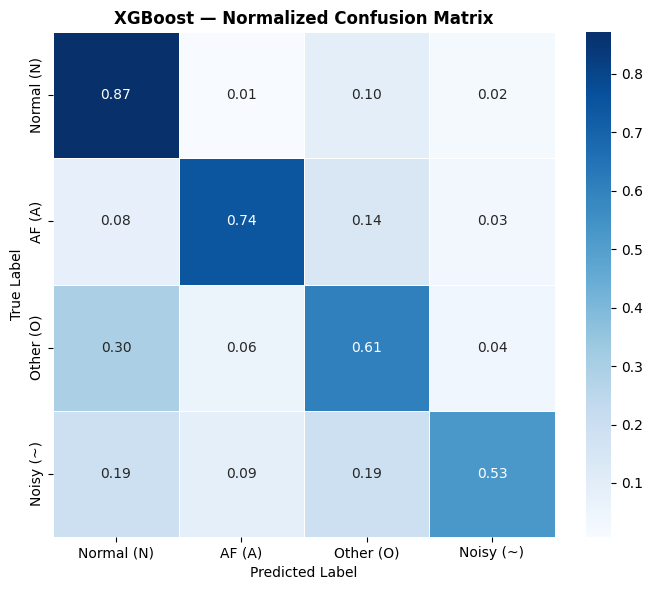


  Random Forest

Accuracy:    0.7617  (76.17%)
Macro F1:    0.6573
AF F1:       0.7315

Classification Report:
              precision    recall  f1-score   support

  Normal (N)     0.8447    0.8564    0.8505      1010
      AF (A)     0.7267    0.7365    0.7315       148
   Other (O)     0.6759    0.5971    0.6341       489
   Noisy (~)     0.3265    0.5614    0.4129        57

    accuracy                         0.7617      1704
   macro avg     0.6435    0.6879    0.6573      1704
weighted avg     0.7687    0.7617    0.7635      1704



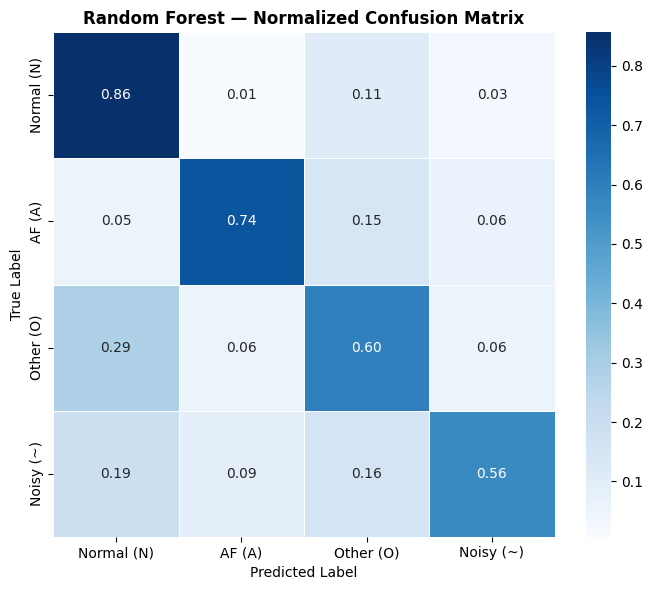


  Gradient Boosting

Accuracy:    0.7635  (76.35%)
Macro F1:    0.6706
AF F1:       0.7303

Classification Report:
              precision    recall  f1-score   support

  Normal (N)     0.8475    0.8475    0.8475      1010
      AF (A)     0.7115    0.7500    0.7303       148
   Other (O)     0.6734    0.6115    0.6409       489
   Noisy (~)     0.3723    0.6140    0.4636        57

    accuracy                         0.7635      1704
   macro avg     0.6512    0.7058    0.6706      1704
weighted avg     0.7699    0.7635    0.7652      1704



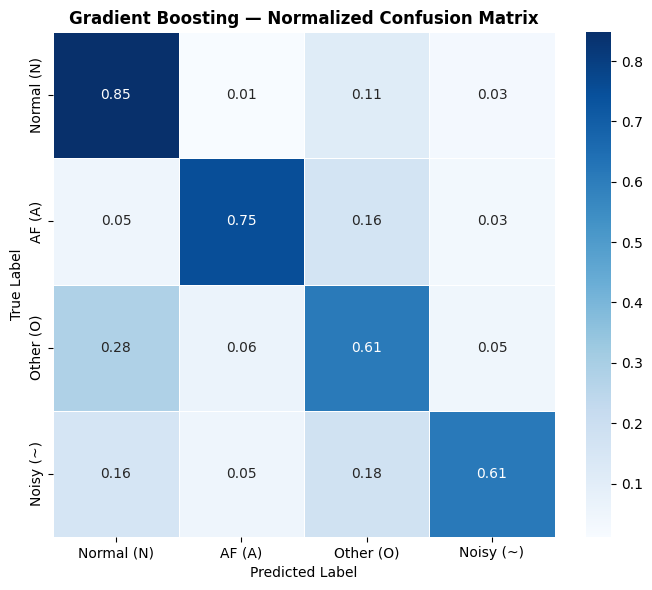


  MODEL COMPARISON SUMMARY
Model                    Accuracy   Macro F1      AF F1
-------------------------------------------------------
XGBoost                    0.7729     0.6714     0.7383
Random Forest              0.7617     0.6573     0.7315
Gradient Boosting          0.7635     0.6706     0.7303


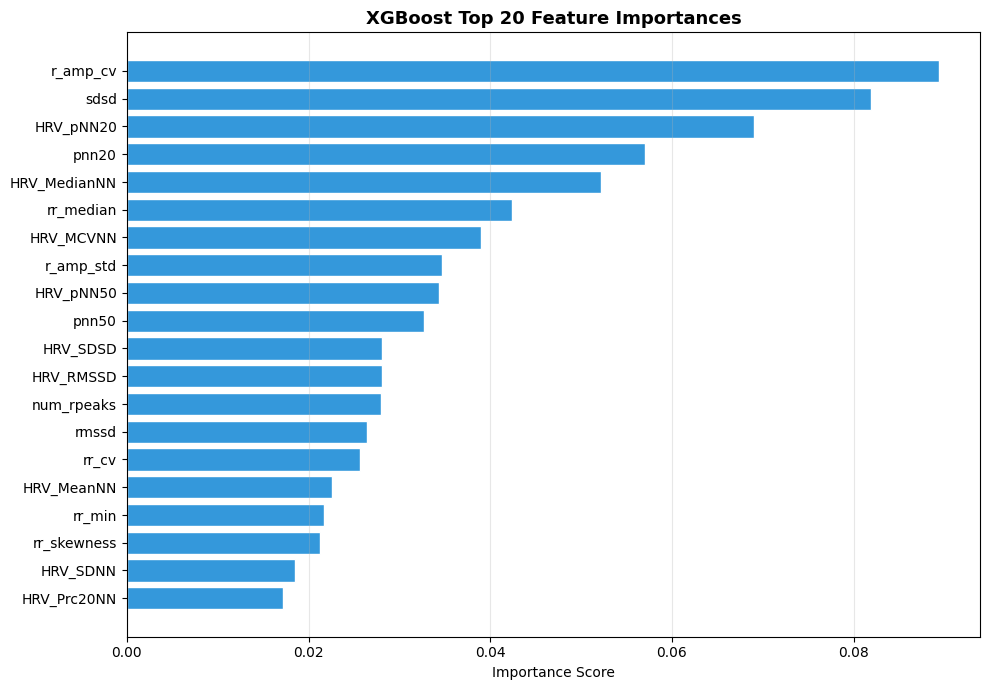


Best model: XGBoost
Saved to:   best_feature_model.pkl
Scaler saved to: feature_scaler.pkl


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ─────────────────────────────────────────────────────────────────────────────
# 1. LOAD AND CLEAN
# ─────────────────────────────────────────────────────────────────────────────

features_df = pd.read_csv("ECG_Processed_Dataset/ecg_features.csv")

print(f"Raw shape:         {features_df.shape}")
print(f"Missing values:\n{features_df.isnull().sum()[features_df.isnull().sum() > 0]}")

features_df = features_df.dropna()
print(f"\nShape after dropna: {features_df.shape}")

label_encoding = {"N": 0, "A": 1, "O": 2, "~": 3}
label_names    = ["Normal (N)", "AF (A)", "Other (O)", "Noisy (~)"]

X = features_df.drop(columns=["record_id", "label"]).values
y = features_df["label"].map(label_encoding).values

print(f"\nClass distribution before split:")
for label, idx in label_encoding.items():
    print(f"  {label}: {np.sum(y == idx)}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. TRAIN TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = 42
)

print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. SMOTE ON TRAIN ONLY
# ─────────────────────────────────────────────────────────────────────────────

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nClass distribution after SMOTE:")
for label, idx in label_encoding.items():
    print(f"  {label}: {np.sum(y_train_bal == idx)}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. SCALE FEATURES
# ─────────────────────────────────────────────────────────────────────────────

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_bal)   # fit only on train
X_test_sc   = scaler.transform(X_test)            # apply same scaler to test

# ─────────────────────────────────────────────────────────────────────────────
# 5. DEFINE MODELS
# ─────────────────────────────────────────────────────────────────────────────

models = {
    "XGBoost": XGBClassifier(
        n_estimators      = 500,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = "mlogloss",
        random_state      = 42,
        n_jobs            = -1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 500,
        max_depth    = 20,
        min_samples_split = 5,
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = -1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators  = 300,
        max_depth     = 5,
        learning_rate = 0.05,
        subsample     = 0.8,
        random_state  = 42
    ),
}

# ─────────────────────────────────────────────────────────────────────────────
# 6. TRAIN, EVALUATE, AND PLOT EACH MODEL
# ─────────────────────────────────────────────────────────────────────────────

results = {}

for model_name, model in models.items():
    print("\n" + "=" * 60)
    print(f"  {model_name}")
    print("=" * 60)

    # Train
    model.fit(X_train_sc, y_train_bal)

    # Predict
    y_pred = model.predict(X_test_sc)

    # Metrics
    acc     = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    af_f1   = f1_score(y_test, y_pred, average=None)[1]   # AF class specifically

    results[model_name] = {
        "accuracy":  acc,
        "macro_f1":  macro_f1,
        "af_f1":     af_f1,
        "y_pred":    y_pred
    }

    print(f"\nAccuracy:    {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"AF F1:       {af_f1:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=label_names, digits=4))

    # Confusion matrix
    cm  = confusion_matrix(y_test, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f"{model_name} — Normalized Confusion Matrix",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{model_name.replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. COMPARISON SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'Macro F1':>10} {'AF F1':>10}")
print("-" * 55)
for name, r in results.items():
    print(f"{name:<22} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['af_f1']:>10.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. FEATURE IMPORTANCE (XGBoost)
# ─────────────────────────────────────────────────────────────────────────────

feat_names  = features_df.drop(columns=["record_id", "label"]).columns.tolist()
importances = models["XGBoost"].feature_importances_
sorted_idx  = np.argsort(importances)[::-1][:20]   # top 20

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    [feat_names[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]],
    color="#3498db", edgecolor="white"
)
ax.set_title("XGBoost Top 20 Feature Importances",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 9. SAVE BEST MODEL
# ─────────────────────────────────────────────────────────────────────────────

import joblib

best_model_name = max(results, key=lambda k: results[k]["macro_f1"])
best_model      = models[best_model_name]

joblib.dump(best_model, "best_feature_model.pkl")
joblib.dump(scaler,     "feature_scaler.pkl")

print(f"\nBest model: {best_model_name}")
print(f"Saved to:   best_feature_model.pkl")
print(f"Scaler saved to: feature_scaler.pkl")